# This project is attempts to analyze honeypots using an entropy based approach

The data comes from a cowrie SSH honeypot that was setup to analyze what people would do in an SSH honeypot and what 

In [3]:
print('hello world')

hello world


## first we need to normalize data seen in the data set so we will do analysis on completely normalized data

In [19]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster


df = pd.read_csv('datasets/ip_entropies.csv')
df['total_sessions'] = pd.to_numeric(df['total_sessions'], errors='coerce')

df = df.dropna()

# Initial data exploration
print('Head of the dataframe:')
print(df.head())

print('\nDataframe info:')
print(df.info())

print('\nDescriptive statistics:')
print(df.describe())

# Normalizing the data
scaler = MinMaxScaler()
normalized_data = df.dropna()
normalized_data = normalized_data.drop(columns=['src_ip'], axis=1)
normalized_data = scaler.fit_transform(normalized_data)

normalized_data = pd.DataFrame(normalized_data, columns=df.columns[1:])

print("NORMALIZED STATISTICS")
print('\nHead of the normalized dataframe:')
print(normalized_data.head())

print('\nNormalized dataframe info:')
print(normalized_data.info())

print('\nNormalized descriptive statistics:')
print(normalized_data.describe())


Head of the dataframe:
         src_ip  total_sessions  username_entropy  password_entropy  \
0   1.117.26.65             3.0          0.918296          1.584963   
1   1.13.79.144             1.0          0.000000          0.000000   
2   1.14.155.39             3.0          0.000000          0.000000   
3  1.158.136.26             3.0          0.918296          1.584963   
4  1.180.230.98             1.0          0.000000          0.000000   

   command_entropy  
0         1.000000  
1         0.000000  
2         4.247928  
3         1.000000  
4         0.000000  

Dataframe info:
<class 'pandas.core.frame.DataFrame'>
Index: 5077 entries, 0 to 5077
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   src_ip            5077 non-null   object 
 1   total_sessions    5077 non-null   float64
 2   username_entropy  5077 non-null   float64
 3   password_entropy  5077 non-null   float64
 4   command_entropy   5

## now that we have normalized the data we can look at some explorative stats to see what is happening in the data frame

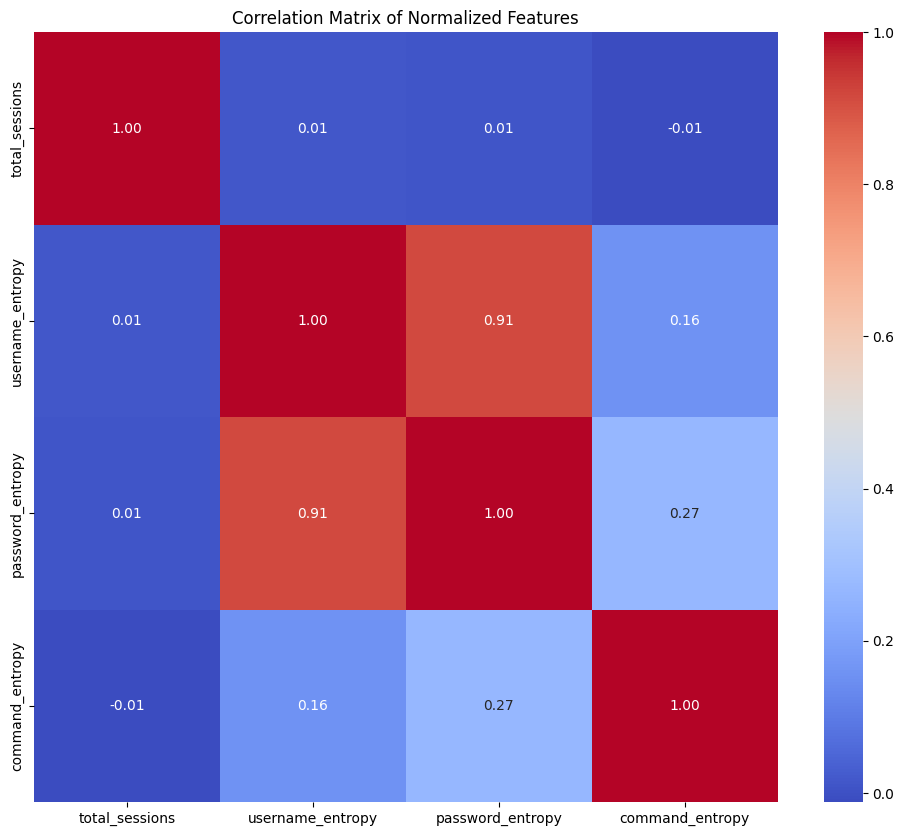

In [20]:
correlation_matrix = normalized_data.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Normalized Features')
plt.show()  

# now we can make a dendrogram to better understand the clusters we may have in the data

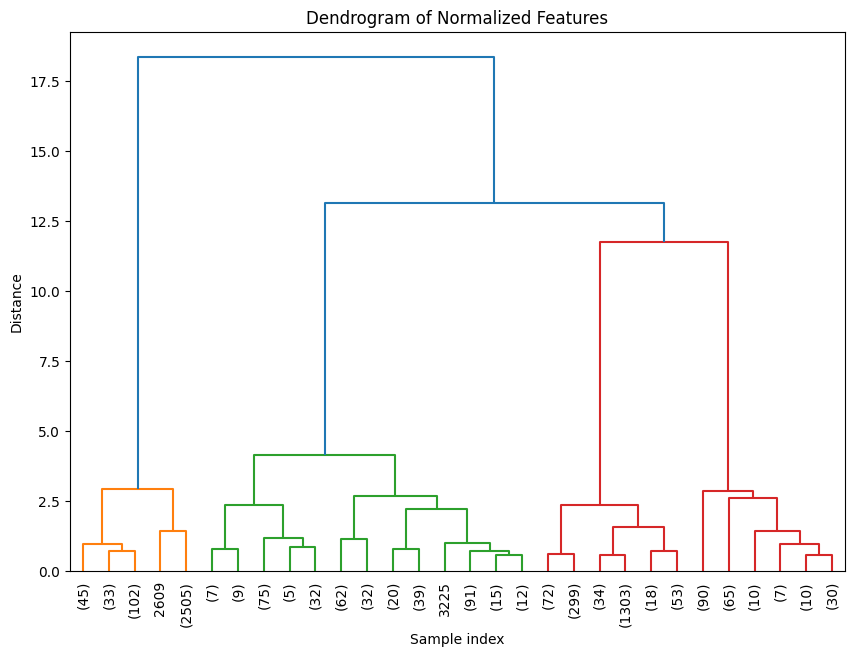

In [23]:
# make an initial dendrogram to better undertand the clusters we may have in the data
linked = linkage(normalized_data, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(
    linked,
    truncate_mode='lastp',   # or 'level'
    p=30,                    # show only last 30 merged clusters
    show_leaf_counts=True,
    leaf_rotation=90,
)
plt.title('Dendrogram of Normalized Features')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()  